# Tareas con los datos nuevos
- quitar los spills
- rehacer los plots sin los spills
- hacer la resta bkg+sig-bkg (bin a bin)
- scatter y sacar conclusiones de todo esto



In [95]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

pltext.style()

In [96]:
datapath = "/home/usc/ie/tam/nicf_first_semester/NiCf_analysis/teresa_analysis/"    #ahora los csv están en mi carpeta
filename_bkg = "1766_uncut_15kevents.csv"
data_bkg     = pd.read_csv(datapath+filename_bkg)

filename_sig = "1767_uncut_15kevents.csv"
data_sig     = pd.read_csv(datapath+filename_sig)


In [97]:
data_bkg

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids
0,0.0,76264.181597,79.0,27.0,2.0,9.0,3.0
1,0.0,76273.067467,209.0,118.0,55.0,3.0,18.0
2,1.0,209221.084343,103.0,114.0,19.0,13.0,12.0
3,1.0,209223.152791,119.0,114.0,19.0,12.0,4.0
4,1.0,209233.144440,175.0,114.0,19.0,10.0,10.0
...,...,...,...,...,...,...,...
1433051,201316.0,459565.065760,111.0,97.0,92.0,1.0,6.0
1433052,201316.0,459565.813249,82.0,94.0,11.0,6.0,8.0
1433053,201316.0,459568.619830,164.0,32.0,75.0,8.0,9.0
1433054,201317.0,461939.606112,372.0,114.0,19.0,3.0,18.0


In [98]:
data_sig

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids
0,0.0,53683.787124,117.0,108.0,3.0,14.0,13.0
1,0.0,53691.537798,100.0,102.0,22.0,10.0,10.0
2,1.0,63479.663380,83.0,12.0,1.0,15.0,5.0
3,1.0,63480.392541,133.0,36.0,46.0,13.0,12.0
4,1.0,63496.106182,180.0,96.0,8.0,15.0,5.0
...,...,...,...,...,...,...,...
3361704,455342.0,492800.972765,237.0,78.0,33.0,11.0,11.0
3361705,455342.0,492801.767311,123.0,85.0,93.0,4.0,1.0
3361706,455342.0,492801.914035,140.0,20.0,81.0,17.0,15.0
3361707,455342.0,492802.180405,221.0,100.0,24.0,2.0,0.0


El proceso es el siguiente:

$^{252}\text{Cf}\rightarrow ^{148}\text{Ba}+^{106}\text{Mo}+4n$

$^{58}\text{Ni}+n\rightarrow ^{59}\text{Ni}+\gamma$

Los fotones son los que se detectan, vemos que en este run detectamos 1433056 fotones (hits) de background. Para organizar esta gigantesca información definimos los "eventos", que corresponden a la toma de datos en un intervalo de tiempo de 500 microsegundos(??), cada uno con un número variable de fotones que llegan al WCTE. Indexamos los eventos con el event_id. En estos eventos debemos separar el "ruido" de los candidates (fotones registrados que provienen del decay del $^{58}\text{Ni}$).

Como me interesan los eventos agrupo los hits en su evento correspindiente con .groupby. Sumo hit_pmt_charges (carga total en cada evento), cuento cuántos hits tiene cada evento (cuántos fotones tiene cada evento), y la RMS del tiempo (si trms es pequeña los hits han llegado casi al mismo tiempo al PMT en este evento).

In [99]:
data_by_event_bkg=data_bkg.groupby("event_id")

total_charge_by_event_bkg = data_by_event_bkg["hit_pmt_charges"].sum() #data_by_event["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_event_bkg = data_by_event_bkg.size() #.size() devuelve el nº de elementos, osea el nº de hits en cada evento
total_trms_by_event_bkg  = data_by_event_bkg["hit_pmt_calibrated_times"].std() #.std() ya lo calcula q facil, pero por q se le llama total_trms?? No hay solo una?

data_by_event_sig=data_sig.groupby("event_id")
total_charge_by_event_sig=data_by_event_sig["hit_pmt_charges"].sum()
total_nhits_by_event_sig = data_by_event_sig.size()
total_trms_by_event_sig  = data_by_event_sig["hit_pmt_calibrated_times"].std()

Hemos almacenado la carga total por evento, el nº de hits por evento y la trms por evento en series: total_charge_by_event_bkg, total_nhits_by_event_bkg, total_trms_by_event_bkg (igual para los datos de señal). Ahora hacemos un gráfico de dispersión (scatter plot, no une los puntos) de cada serie frente el índice que indexa cada evento.

plt.scatter(x.index, y.values) ; .index indexa los elementos de la serie y coge los índices, .values da los valores

Text(0.5, 1.0, 'signal')

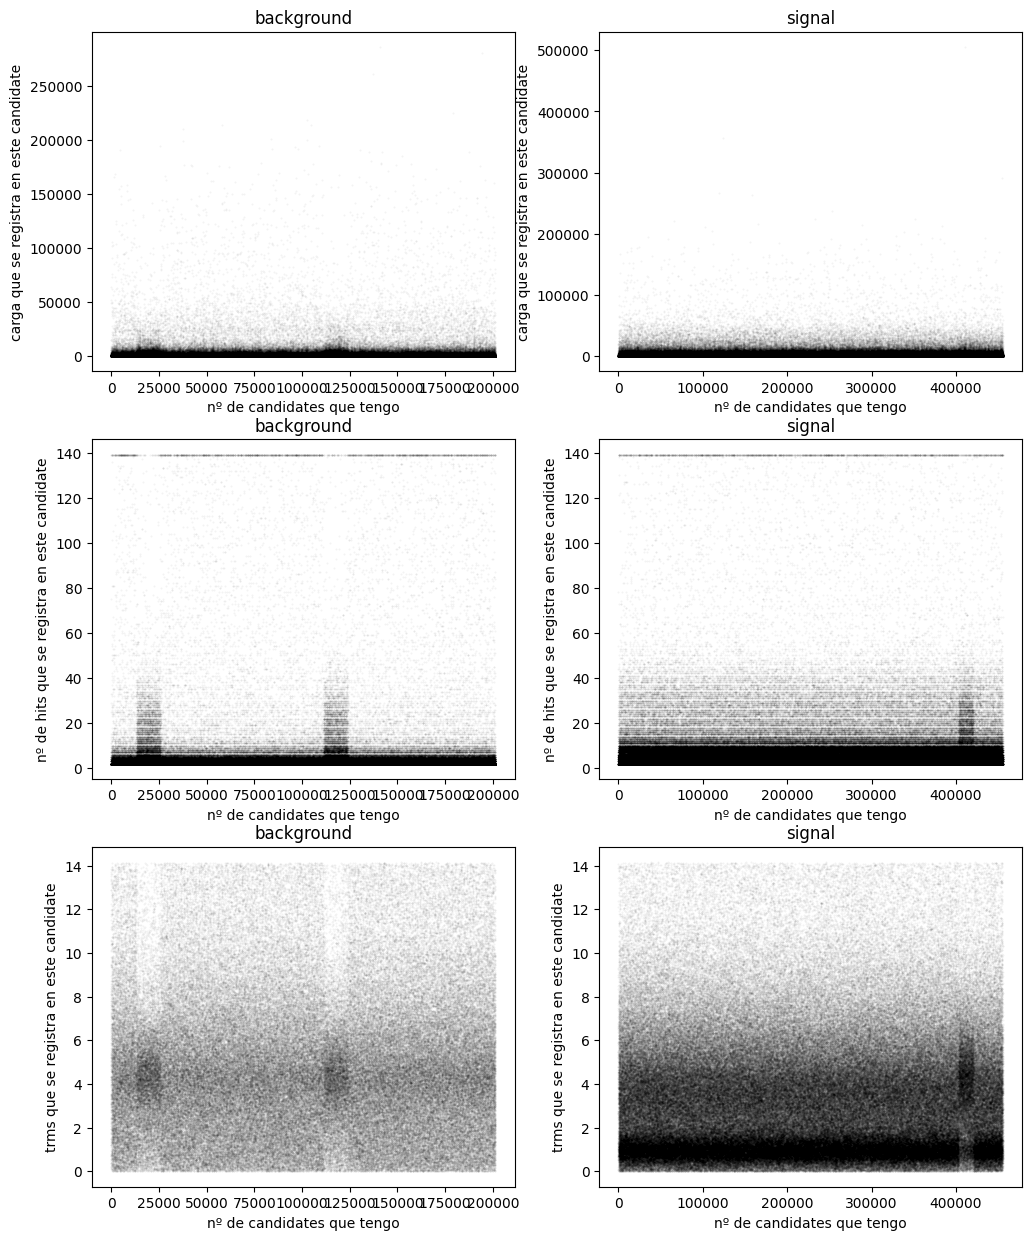

In [100]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("signal")

subplot(3)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(4)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal")

subplot(5)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("background")

subplot(6)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("signal")


## Candidates buenos

Utilizaremos el scatter "nº total de hits de cada candidate vs nº de candidate" para eliminar los eventos que no nos interesan y quedarnos con los candidates buenos. Hago de nuevo este scatter:

Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

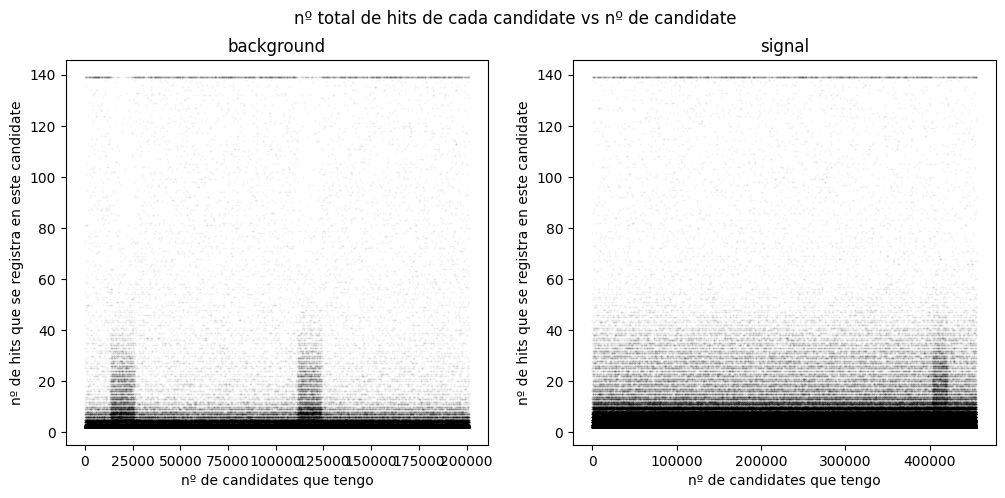

In [101]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

In [102]:
#quiero quitar los spills y los que saturan

#lo lógico primero es bucar cuál es el valor exacto de saturación:
max_value_of_total_nhits_by_event_bkg = total_nhits_by_event_bkg.max()  #aquí .max() va con () porque realiza un cálculo
print(f"{max_value_of_total_nhits_by_event_bkg} es el valor al que satura el nº de hits en los candidates para bkg")

#ahora quiero agrupar los eventos en los que este valor satura, filtrando los eventos en los que total_nhits_by_event_bkg coincida (==) con max_value_of_total_nhits_by_event_bkg
events_saturating_bkg = total_nhits_by_event_bkg[total_nhits_by_event_bkg == max_value_of_total_nhits_by_event_bkg]
print(f"{events_saturating_bkg.size} eventos de bkg que saturan a este valor") #ojo! sin ()

#ahora quiero quitar estos eventos:

#total_nhits_by_event_bkg_without_saturation = total_nhits_by_event_bkg - events_saturating
#esto no funciona xq son series de pandas
#uso mejor .drop(x), que elimina el índice x de una serie

indices_saturating_bkg = events_saturating_bkg.index
print(indices_saturating_bkg)
total_nhits_by_event_bkg_spills = total_nhits_by_event_bkg.drop(indices_saturating_bkg)    #serie sin los valores que saturan

#igual para signal
max_value_of_total_nhits_by_event_sig = total_nhits_by_event_sig.max()
print(f"{max_value_of_total_nhits_by_event_sig} es el valor al que satura el nº de hits en los candidates para sig")
events_saturating_sig = total_nhits_by_event_sig[total_nhits_by_event_sig == max_value_of_total_nhits_by_event_sig]
print(f"{events_saturating_sig.size} eventos de sig que saturan a este valor")
indices_saturating_sig = events_saturating_sig.index
print(indices_saturating_sig)
total_nhits_by_event_sig_spills = total_nhits_by_event_sig.drop(indices_saturating_sig)


139 es el valor al que satura el nº de hits en los candidates para bkg
1888 eventos de bkg que saturan a este valor
Index([    57.0,    182.0,    443.0,    593.0,    651.0,    666.0,    670.0,
          678.0,    777.0,    877.0,
       ...
       200196.0, 200348.0, 200659.0, 200871.0, 200887.0, 200913.0, 201052.0,
       201076.0, 201193.0, 201249.0],
      dtype='float64', name='event_id', length=1888)
139 es el valor al que satura el nº de hits en los candidates para sig
1958 eventos de sig que saturan a este valor
Index([   438.0,    513.0,    752.0,    799.0,    891.0,    913.0,   1076.0,
         1105.0,   1638.0,   1821.0,
       ...
       454490.0, 454536.0, 454679.0, 454697.0, 454720.0, 454892.0, 455098.0,
       455188.0, 455309.0, 455327.0],
      dtype='float64', name='event_id', length=1958)


Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

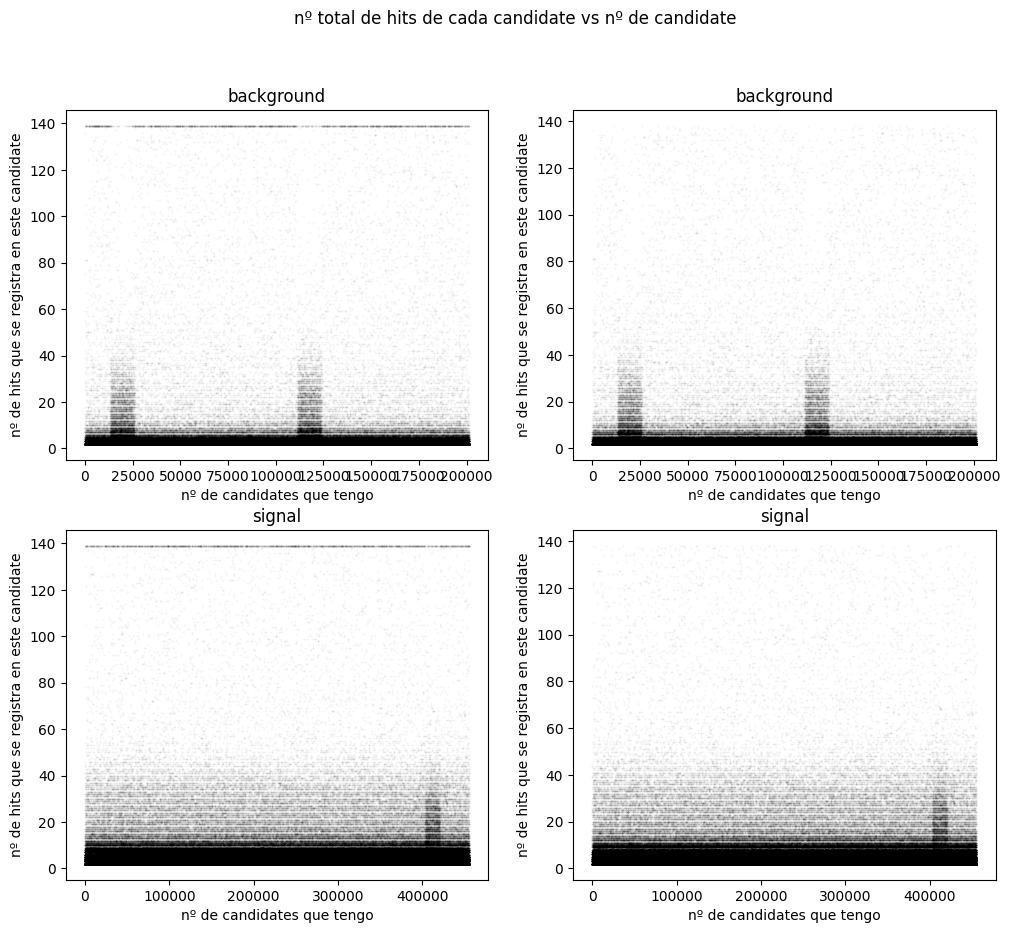

In [103]:
subplot = pltext.canvas(4)      #scattereo las dos (con y sin candidates saturantes) para verlo bien

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_nhits_by_event_bkg_spills.index, total_nhits_by_event_bkg_spills.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(3)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal")

subplot(4)
plt.scatter(total_nhits_by_event_sig_spills.index, total_nhits_by_event_sig_spills.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

(390000.0, 440000.0)

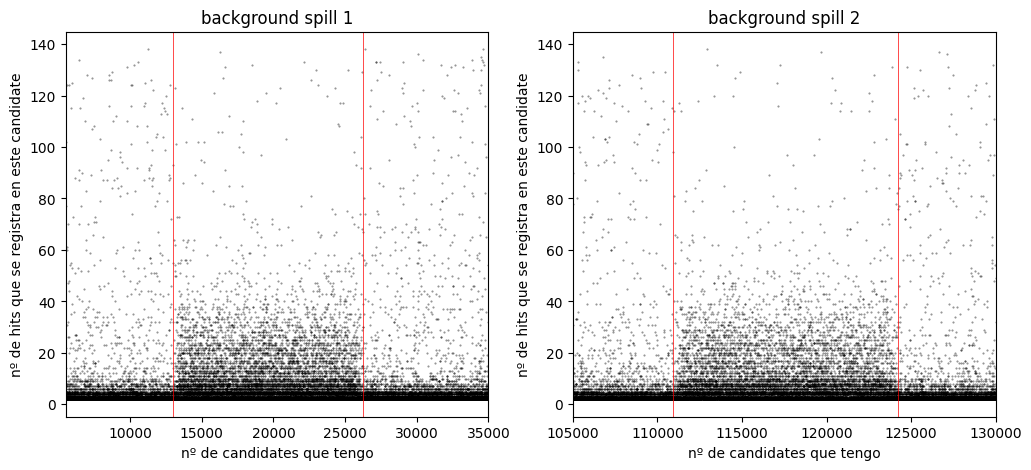

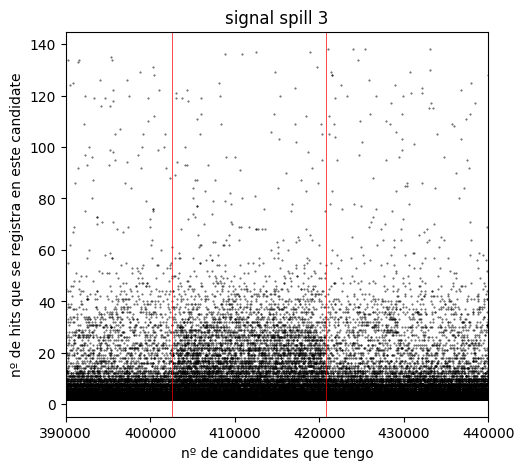

In [104]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_event_bkg_spills.index, total_nhits_by_event_bkg_spills.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background spill 1")

x_lines_spill1 = [13000, 26250]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill1:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(5500, 35000)
#plt.ylim(0,140)

subplot(2)
plt.scatter(total_nhits_by_event_bkg_spills.index, total_nhits_by_event_bkg_spills.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background spill 2")

x_lines_spill2 = [110900, 124250]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill2:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(105000, 130000)
#plt.ylim(0,140)

subplot = pltext.canvas(1)
subplot(1)
plt.scatter(total_nhits_by_event_sig_spills.index, total_nhits_by_event_sig_spills.values, s=0.2, alpha=0.7)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal spill 3")

x_lines_spill3 = [402600, 420800]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill3:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(390000, 440000)
#plt.ylim(0,140)


Text(0.5, 1.0, 'signal')

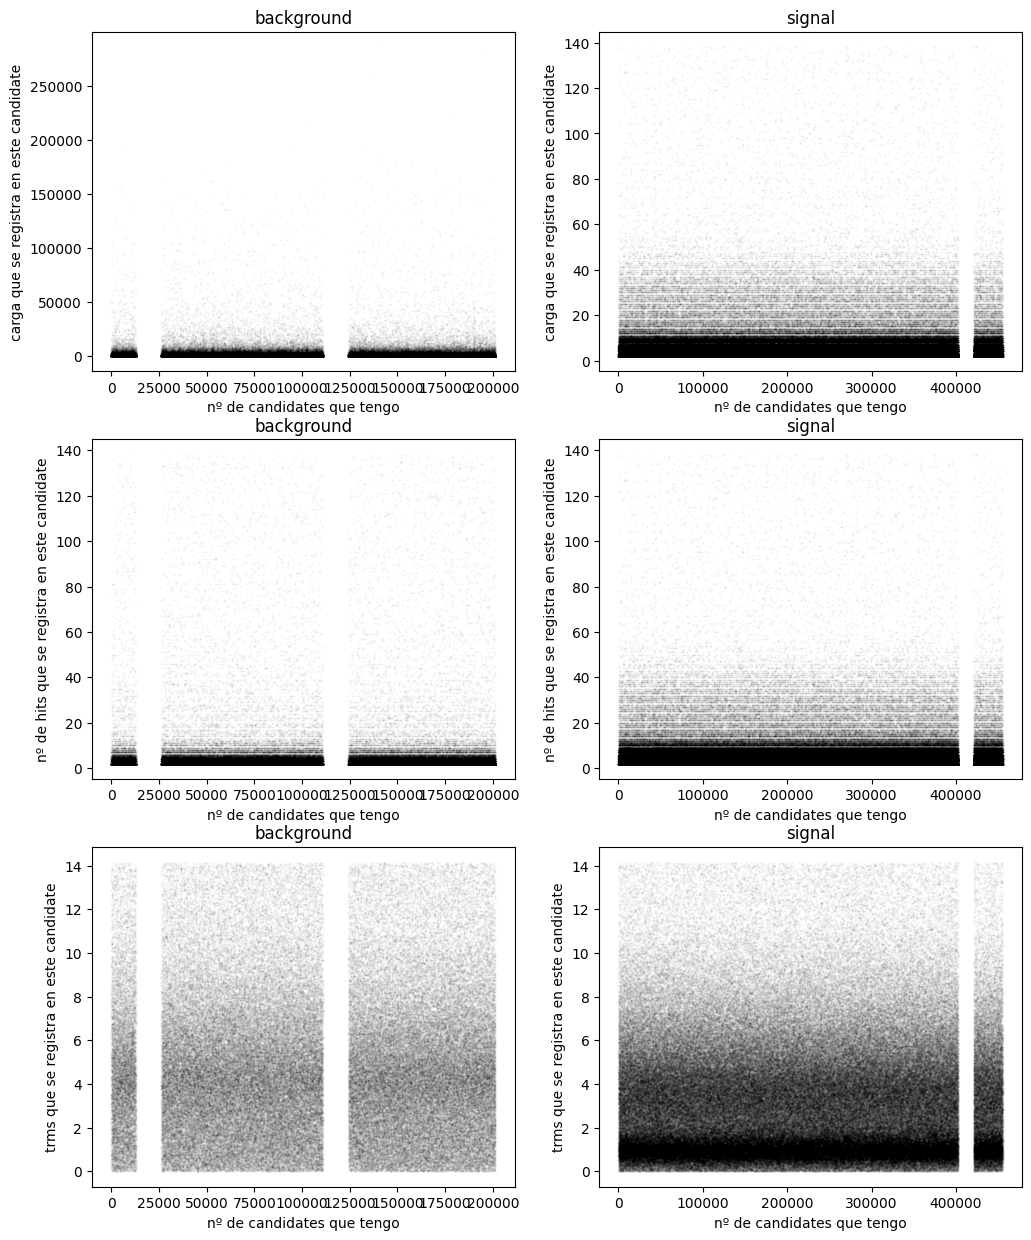

In [105]:
x_min_s1 = 13000; x_max_s1 = 26250
x_min_s2 = 110900; x_max_s2 = 124250
x_min_s3 = 402600; x_max_s3 = 420800


#series que hay que quitar
spill_1 = total_nhits_by_event_bkg_spills[(total_nhits_by_event_bkg_spills.index >= x_min_s1) & (total_nhits_by_event_bkg_spills.index <= x_max_s1)]
spill_2 = total_nhits_by_event_bkg_spills[(total_nhits_by_event_bkg_spills.index >= x_min_s2) & (total_nhits_by_event_bkg_spills.index <= x_max_s2)]
spill_3 = total_nhits_by_event_sig_spills[(total_nhits_by_event_sig_spills.index >= x_min_s3) & (total_nhits_by_event_sig_spills.index <= x_max_s3)]

#hay que concatenar sus índices, NO SUMAR
combined_indices_bkg = pd.concat([spill_1, spill_2]).index

total_nhits_by_event_bkg_clean = total_nhits_by_event_bkg_spills.drop(combined_indices_bkg)
total_charge_by_event_bkg_clean = total_charge_by_event_bkg.loc[total_nhits_by_event_bkg_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_event_bkg_clean = total_trms_by_event_bkg.loc[total_nhits_by_event_bkg_clean.index]

total_nhits_by_event_sig_clean = total_nhits_by_event_sig_spills.drop(spill_3.index)
total_charge_by_event_sig_clean = total_charge_by_event_sig.loc[total_nhits_by_event_sig_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_event_sig_clean = total_trms_by_event_sig.loc[total_nhits_by_event_sig_clean.index]


subplot = pltext.canvas(6)
subplot(1)
plt.scatter(total_charge_by_event_bkg_clean.index, total_charge_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("background")

subplot(2)
plt.scatter(total_nhits_by_event_sig_clean.index, total_nhits_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("signal")

subplot(3)
plt.scatter(total_nhits_by_event_bkg_clean.index, total_nhits_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background")

subplot(4)
plt.scatter(total_nhits_by_event_sig_clean.index, total_nhits_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("signal")

subplot(5)
plt.scatter(total_trms_by_event_bkg_clean.index, total_trms_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("background")

subplot(6)
plt.scatter(total_trms_by_event_sig_clean.index, total_trms_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("signal")


# Distribución de carga total por evento

Text(0.5, 0.98, 'Distribución de carga total por evento')

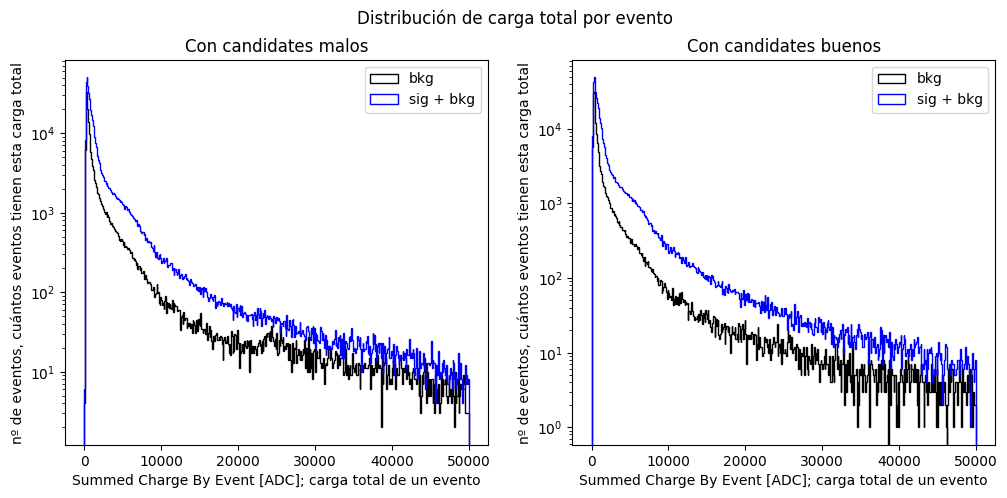

In [106]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_charge_by_event_bkg, 500, histtype="step", label="bkg", range=(0, 50e3))   #500 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_event_sig, 500, histtype="step", label="sig + bkg", range=(0, 50e3))
plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Con candidates malos")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_charge_by_event_bkg_clean, 500, histtype="step", label="bkg", range=(0, 50e3))   #500 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_event_sig_clean, 500, histtype="step", label="sig + bkg", range=(0, 50e3))
plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Con candidates buenos")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de carga total por evento")

Sea la carga total depositada [Analog-to-Digital Converter] $\propto$ a $E_{depositada}$. En los candidates buenos vemos que:

- Región de baja energía: muchos eventos caen en esta región, con signal por encima de bkg.
- Región intermedia: aquí signal decae más lentamente que bkg, i.e., la señal tiene más probabilidad de producir eventos energéticos. meseta(??)
- Región de alta carga: apenas hay fondo ($10^{0,1}$), signal mantiene una cola más larga. 

La mejor región para separar bkg de signal es la intermedia, desde 0 hasta 50e3 en el eje x (carga total)

El eje y en log ajusta escalas para poder ver bien tanto los eventos de alta como baja carga $\equiv$ energía. Los bins logarítmicos ajustan la resolución: bins estrechos en baja energía (para ver estructura fina) y bins anchos en alta energía (porque aquí hay pocos eventos y no necesito tanto detalle).

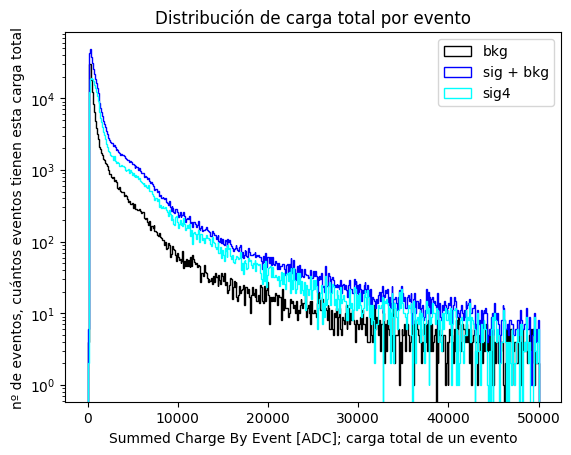

In [107]:
weights_sig_charge = np.ones_like(total_charge_by_event_sig_clean)
weights_bkg_charge_4 = -  1*np.ones_like(total_charge_by_event_bkg_clean)   #bkg = sig+bkg perfecto

all_charge = np.concatenate([total_charge_by_event_sig_clean, total_charge_by_event_bkg_clean])   #lo junto todo
all_weights_charge_4 = np.concatenate([weights_sig_charge, weights_bkg_charge_4])

plt.hist(total_charge_by_event_bkg_clean, 500, histtype="step", alpha=1, label="bkg", range=(0, 50e3))
plt.hist(total_charge_by_event_sig_clean, 500, histtype="step", alpha=1, label="sig + bkg", range=(0, 50e3))
plt.hist(all_charge, 500, weights=all_weights_charge_4, histtype="step", color="cyan", alpha=1, label="sig4", range=(0, 50e3))
plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento")
plt.yscale("log")
plt.legend()

# Distribución de hits por evento

Text(0.5, 0.98, 'Distribución de hits por evento')

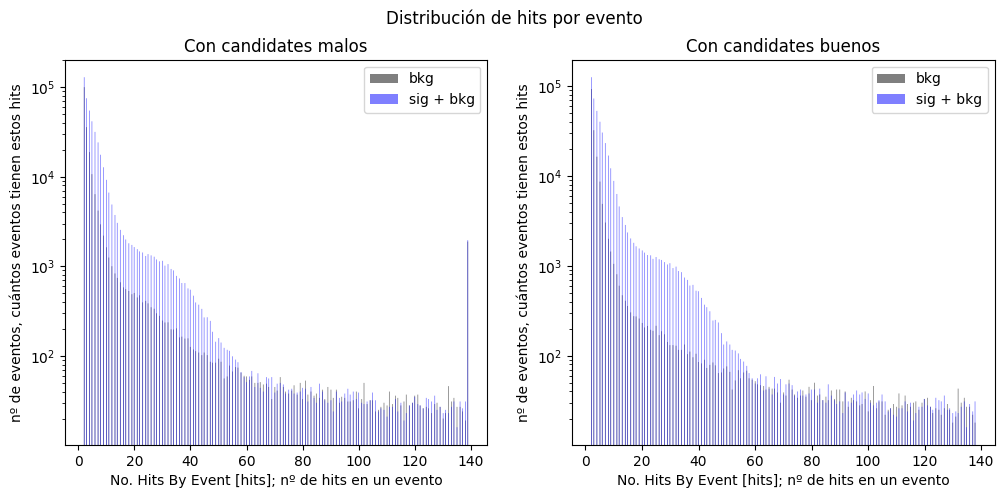

In [108]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_nhits_by_event_bkg, 500, histtype="stepfilled", label="bkg", alpha=0.5)   #500 bins; histtype = "stepfilled" rellena el bin
plt.hist(total_nhits_by_event_sig, 500, histtype="stepfilled", label="sig + bkg", alpha=0.5)
plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Con candidates malos")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_nhits_by_event_bkg_clean, 500, histtype="stepfilled", label="bkg", alpha=0.5)   #500 bins; histtype = "stepfilled" rellena el bin
plt.hist(total_nhits_by_event_sig_clean, 500, histtype="stepfilled", label="sig + bkg", alpha=0.5)
plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Con candidates buenos")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de hits por evento")

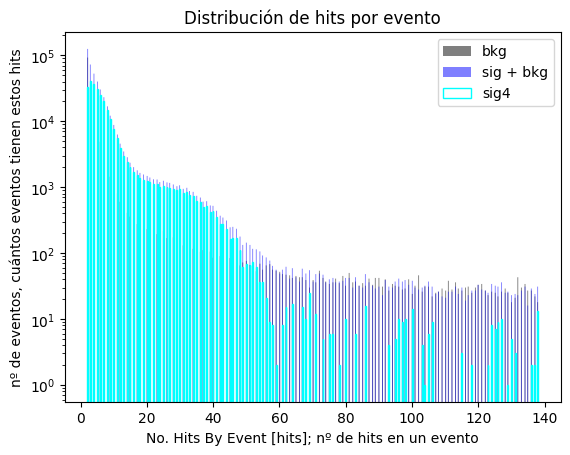

In [109]:
weights_sig_nhits = np.ones_like(total_nhits_by_event_sig_clean)
weights_bkg_nhits_4 = -  1*np.ones_like(total_nhits_by_event_bkg_clean)   #bkg = sig+bkg perfecto

all_nhits = np.concatenate([total_nhits_by_event_sig_clean, total_nhits_by_event_bkg_clean])   #lo junto todo
all_weights_nhits_4 = np.concatenate([weights_sig_nhits, weights_bkg_nhits_4])

plt.hist(total_nhits_by_event_bkg_clean, 500, histtype="stepfilled", alpha=0.5, label="bkg")
plt.hist(total_nhits_by_event_sig_clean, 500, histtype="stepfilled", alpha=0.5, label="sig + bkg")
plt.hist(all_nhits, 500, weights=all_weights_nhits_4, histtype="step", color="cyan", alpha=1, label="sig4")
plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento")
plt.yscale("log")
plt.legend()

Bins discretos (con separación) porque el nº de hits en un evento es entero. En realidad es que hay bins vacíos de por medio, pero esto se puede ajustar cambiando el número de bins que quiero que grafique (por ej de 500 cambiamos a 50). Con los candidates buenos quitamos el bin en 139, vemos que hay una meseta entre 17 y 40 hits. Si hacemos el corte nos quedamos con los eventos que tienen < 60 hits. 

# Distribución de tRMS por evento

Text(0.5, 0.98, 'Distribución de tRMS por evento')

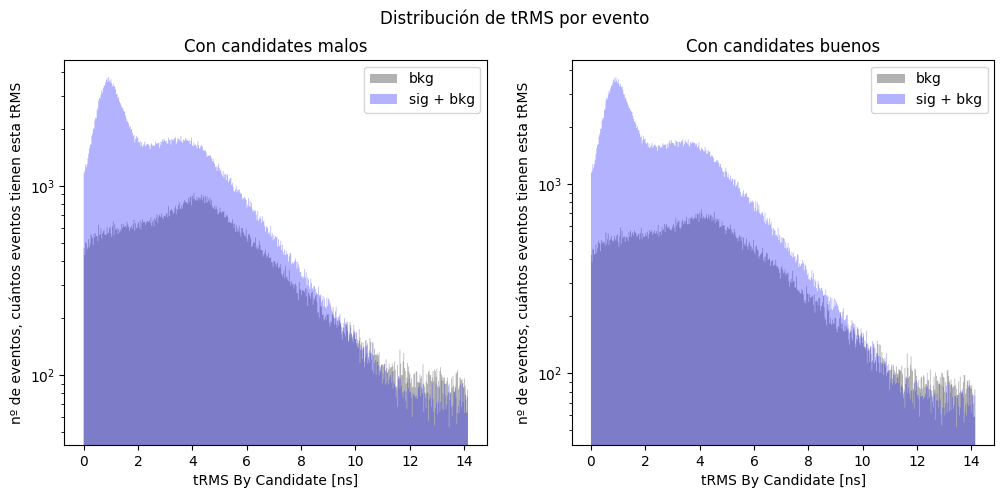

In [110]:
subplot = pltext.canvas(2)

#total_trms_by_event_pure_sig = total_trms_by_event_sig_clean - total_trms_by_event_bkg_clean  Esto no funciona porque son series de longitudes diferentes

weights_sig_trms = np.ones_like(total_trms_by_event_sig_clean)
weights_bkg_trms_4 = -  1*np.ones_like(total_trms_by_event_bkg_clean)   #bkg = sig+bkg perfecto

all_trms = np.concatenate([total_trms_by_event_sig_clean, total_trms_by_event_bkg_clean])   #lo junto todo
all_weights_trms_4 = np.concatenate([weights_sig_trms, weights_bkg_trms_4])

subplot(1)
plt.hist(total_trms_by_event_bkg, 500, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig, 500, histtype="stepfilled", alpha=0.3, label="sig + bkg")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Con candidates malos")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_trms_by_event_bkg_clean, 500, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig_clean, 500, histtype="stepfilled", alpha=0.3, label="sig + bkg")
#plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, label="sig")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Con candidates buenos")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de tRMS por evento")



La tRMS es la desviación estándar de los tiempos de llegada de los hits en un evento. Si los hits que forman un evento llegaran a la vez, el tRMS sería cero, i.e., cuanto más dispersos en el tiempo, mayor será la tRMS. Vemos que el pico corresponde a que hay muchos eventos con tRMS pequeña (los hits llegan casi a la vez). Que haya esta diferencia tan marcada entre bkg y sig+bkg sugiere que el detector tiene buena resolución para identificar candidates deseados basándose en el tiempo.

Si quiero hacer un corte para quedarme solo con los eventos más probables de ser reales lo haría en tRMS < 2 [ns]: conservo gran parte de sig (pico) y elimino gran parte del bkg.

Los argumentos de hist son:

matplotlib.pyplot.hist(x, bins=None, *, range=None, density=False, weights=None, cumulative=False, bottom=None, histtype='bar', align='mid', orientation='vertical', rwidth=None, log=False, color=None, label=None, stacked=False, data=None, **kwargs)

* weights(n,) array-like or None, default: None
An array of weights, of the same shape as x. Each value in x only contributes its associated weight towards the bin count (instead of 1). If density is True, the weights are normalized, so that the integral of the density over the range remains 1.

Para restar los histogramas lo más fácil es definir sus pesos (weights) como +1 para sig y como -1 para bkg. Con n.ones_like() creo un array de unos (1) con la misma longitud que los datos de la serie que le ponga. Lógicamente debo escalar a la longitud de cada serie normalizando, y lo hago para el bkg con -normalization

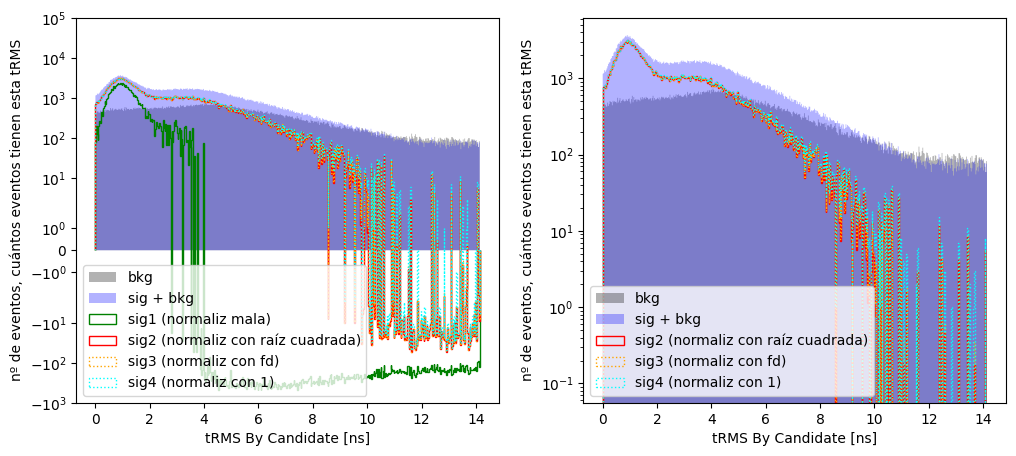

In [111]:
#total_trms_by_event_pure_sig = total_trms_by_event_sig_clean - total_trms_by_event_bkg_clean  Esto no funciona porque son series de longitudes diferentes

#FACTOR DE NORMALIZACIÓN: para escalar la longitud relativa de ambas series

normalization_trms = len(total_trms_by_event_sig_clean) / len(total_trms_by_event_bkg_clean)    #2.5170285978660036, sig+bkg tiene 2.52 veces más eventos totales que bkg

weights_sig_trms = np.ones_like(total_trms_by_event_sig_clean)

weights_bkg_trms_1 = - normalization_trms*np.ones_like(total_trms_by_event_bkg_clean)   #asume que la densidad de bkg es propto al tamaño de sig+bkg, SOBREESTIMA bkg
weights_bkg_trms_2 = -  1.0353423013098895*np.ones_like(total_trms_by_event_bkg_clean)   #sqrt
weights_bkg_trms_3 = -  1.033093985496943*np.ones_like(total_trms_by_event_bkg_clean)   #fd
weights_bkg_trms_4 = -  1*np.ones_like(total_trms_by_event_bkg_clean)   #bkg = sig+bkg perfecto

all_trms = np.concatenate([total_trms_by_event_sig_clean, total_trms_by_event_bkg_clean])   #lo junto todo

all_weights_trms_1 = np.concatenate([weights_sig_trms, weights_bkg_trms_1])
all_weights_trms_2 = np.concatenate([weights_sig_trms, weights_bkg_trms_2])
all_weights_trms_3 = np.concatenate([weights_sig_trms, weights_bkg_trms_3])
all_weights_trms_4 = np.concatenate([weights_sig_trms, weights_bkg_trms_4])

subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_trms_by_event_bkg_clean, 500, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig_clean, 500, histtype="stepfilled", alpha=0.3, label="sig + bkg")
plt.hist(all_trms, 500, weights=all_weights_trms_1, histtype="step", color="green", alpha=1, label="sig1 (normaliz mala)")
plt.hist(all_trms, 500, weights=all_weights_trms_2, histtype="step", color="red", alpha=1, label="sig2 (normaliz con raíz cuadrada)")    #este creo que valdría
plt.hist(all_trms, 500, weights=all_weights_trms_3, histtype="step", color="orange", alpha=1, linestyle=":", label="sig3 (normaliz con fd)")   #este creo que tb
plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, linestyle=":", label="sig4 (normaliz con 1)")   #este creo que tb
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.yscale("symlog")
plt.ylim(-1e3, 1e5)
plt.legend()

subplot(2)
plt.hist(total_trms_by_event_bkg_clean, 500, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig_clean, 500, histtype="stepfilled", alpha=0.3, label="sig + bkg")
#plt.hist(all_trms, 500, weights=all_weights_trms_1, histtype="step", color="green", alpha=1, label="sig1 (normaliz mala)")
plt.hist(all_trms, 500, weights=all_weights_trms_2, histtype="step", color="red", alpha=1, label="sig2 (normaliz con raíz cuadrada)")    #este creo que valdría
plt.hist(all_trms, 500, weights=all_weights_trms_3, histtype="step", color="orange", alpha=1, linestyle=":", label="sig3 (normaliz con fd)")   #este creo que tb
plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, linestyle=":", label="sig4 (normaliz con 1)")   #este creo que tb
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.yscale("log")
plt.legend()


In [112]:
normalization_trms

2.5170285978660036

In [113]:
#NORMALIZACIÓN PARA LOS WEIGHTS en la región de solo fondo

bins_sqrt = np.linspace(0, 15, 415)  #415 (sqrt{n}) bins de 0 a 15 ns
hist_bkg_sqrt, _ = np.histogram(total_trms_by_event_bkg_clean, bins=bins_sqrt)    #conteos, bordes = np.histogram(datos, bins), los bordes no nos interesan y ponemos _
hist_sig_sqrt, _ = np.histogram(total_trms_by_event_sig_clean, bins=bins_sqrt)

mask_only_bkg_sqrt = bins_sqrt[:-1] > 8     #mask para bins talq ue tRMS>8 [ns] (solo bkg)
#bins[:-1] límites inferior del bin ; > 8 crea un array booleano: True para bins > 8, False para bins ≤ 8
#print(mask_only_bkg_sqrtn)

only_bkg_bkg_sqrt = np.sum(hist_bkg_sqrt[mask_only_bkg_sqrt])  #usamos la región de solo fondo para normalizar
only_bkg_sig_sqrt = np.sum(hist_sig_sqrt[mask_only_bkg_sqrt])
normalization_sqrt = only_bkg_sig_sqrt / only_bkg_bkg_sqrt

#__________________________________________________________________________________
bins_fd = np.linspace(0, 15, 100)  #100 (fd) bins de 0 a 15 ns
hist_bkg_fd, _ = np.histogram(total_trms_by_event_bkg_clean, bins=bins_fd)
hist_sig_fd, _ = np.histogram(total_trms_by_event_sig_clean, bins=bins_fd)

mask_only_bkg_fd = bins_fd[:-1] > 8

only_bkg_bkg_fd = np.sum(hist_bkg_fd[mask_only_bkg_fd])
only_bkg_sig_fd = np.sum(hist_sig_fd[mask_only_bkg_fd])
normalization_fd = only_bkg_sig_fd / only_bkg_bkg_fd


print(f"Factor de normalización por regla de raíz cuadrada: {normalization_sqrt}")
print(f"Factor de normalización por regla de Freedman-Diaconis: {normalization_fd}")

Factor de normalización por regla de raíz cuadrada: 1.0353423013098895
Factor de normalización por regla de Freedman-Diaconis: 1.033093985496943


In [114]:
#para saber el número de bins

#Regla de la raíz cuadrada
n_events_min = min(len(total_trms_by_event_bkg_clean), len(total_trms_by_event_sig_clean))  #usamos el mínimo xq sig+bkg y bkg deben usar los mismos bins para ser comparables
n_bins_sqrt_rule = int(np.sqrt(n_events_min))

#Refla de Freedman-Diaconis, fórmula de google
h_bkg = 2 * (np.percentile(total_trms_by_event_bkg_clean, 75) - np.percentile(total_trms_by_event_bkg_clean, 25)) * len(total_trms_by_event_bkg_clean)**(-1/3)
h_sig = 2 * (np.percentile(total_trms_by_event_sig_clean, 75) - np.percentile(total_trms_by_event_sig_clean, 25)) * len(total_trms_by_event_sig_clean)**(-1/3)

n_bins_bkg = int((total_trms_by_event_bkg_clean.max() - total_trms_by_event_bkg_clean.min()) / h_bkg)
n_bins_sig = int((total_trms_by_event_sig_clean.max() - total_trms_by_event_sig_clean.min()) / h_sig)

n_bins_fd_rule = min(n_bins_bkg, n_bins_sig) #esto no sé si es muy correcto

print(f"nº de bins por regla de raíz cuadrada: {n_bins_sqrt_rule}")
print(f"nº de bins por regla de Freedman-Diaconis: {n_bins_fd_rule}")

nº de bins por regla de raíz cuadrada: 415
nº de bins por regla de Freedman-Diaconis: 91


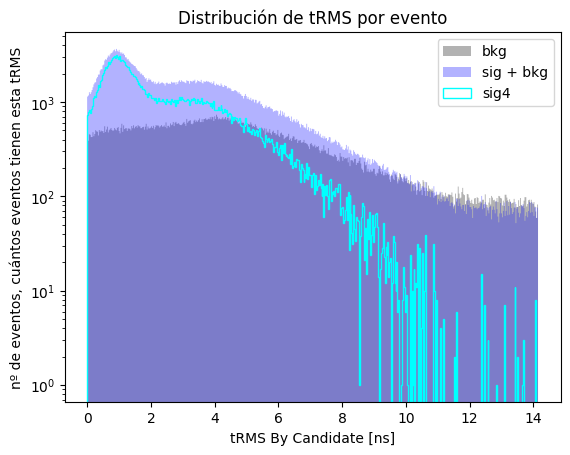

In [115]:
plt.hist(total_trms_by_event_bkg_clean, 500, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig_clean, 500, histtype="stepfilled", alpha=0.3, label="sig + bkg")
plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, label="sig4")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Distribución de tRMS por evento")
plt.yscale("log")
plt.legend()

# Scatters

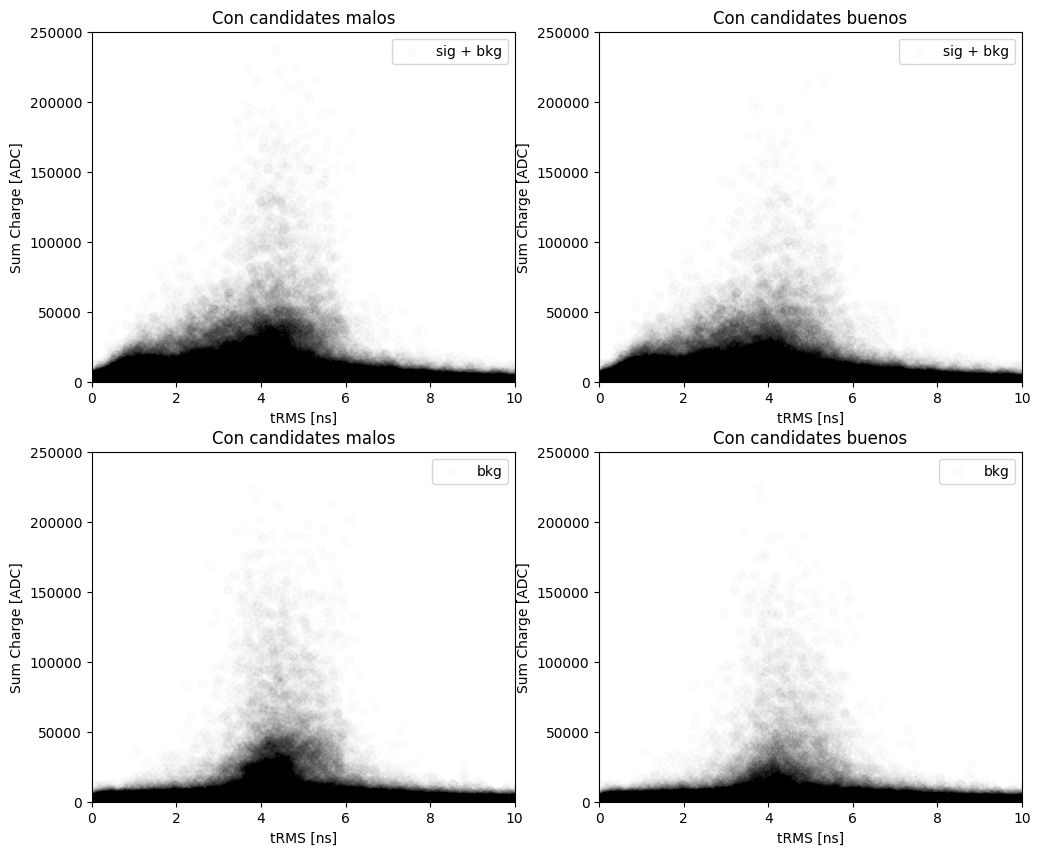

In [136]:
subplot = pltext.canvas(4)

subplot(1)
plt.scatter(total_trms_by_event_sig, total_charge_by_event_sig, alpha=0.01, label="sig + bkg")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates malos")
plt.legend()

subplot(2)
plt.scatter(total_trms_by_event_sig_clean, total_charge_by_event_sig_clean, alpha=0.01, label="sig + bkg")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates buenos")
plt.legend()

subplot(3)
plt.scatter(total_trms_by_event_bkg, total_charge_by_event_bkg, alpha=0.01, label="bkg");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates malos")
plt.legend()

subplot(4)
plt.scatter(total_trms_by_event_bkg_clean, total_charge_by_event_bkg_clean, alpha=0.01, label="bkg");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates buenos")
plt.legend()

#antes calculé sig4, que es la señal pura bin a bin en el histograma, pero no evento a evento. Como no tengo su event_id no puedo scatterear sig4 porque no es un dataset


En estos scatters se representa un evento como un punto (tRMS, Q_tot). Tenemos muchísimos eventos con carga baja, y en 4 [ns] está la señal (acumulación con cargas más altas).

Text(0.5, 1.0, 'Con candidates buenos, bkg')

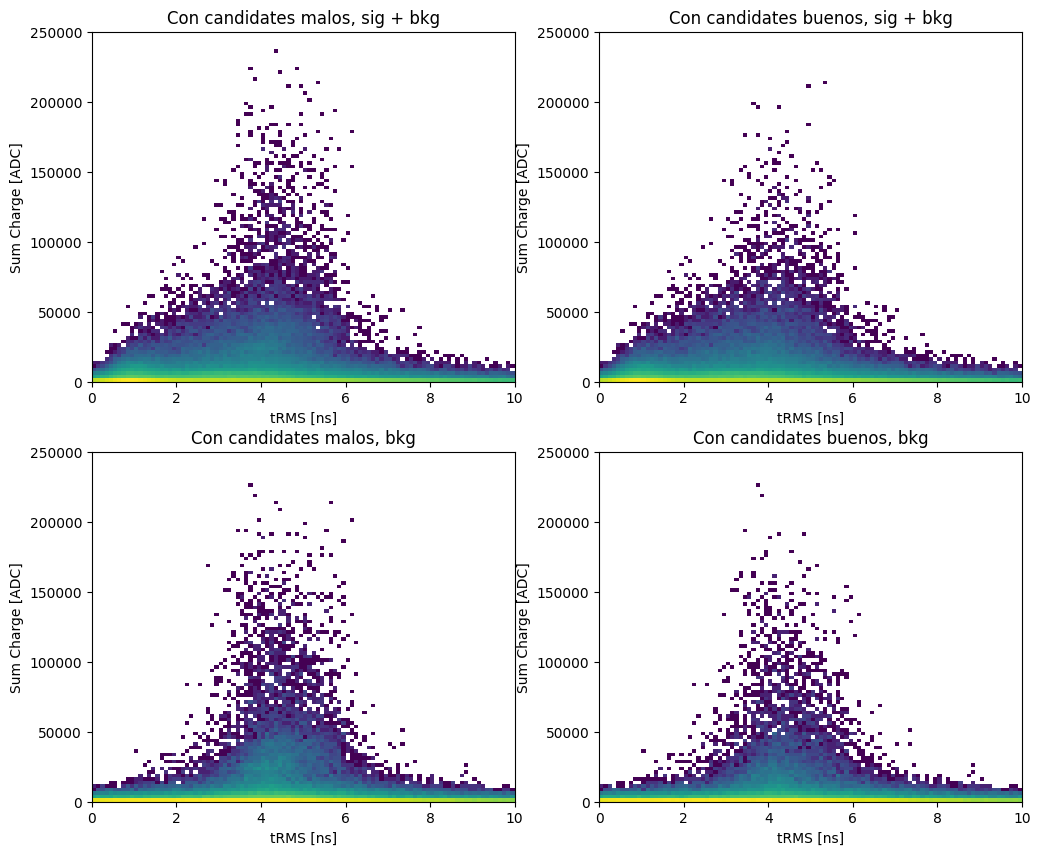

In [139]:
subplot = pltext.canvas(4)

subplot(1)
plt.hist2d(total_trms_by_event_sig, total_charge_by_event_sig, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates malos, sig + bkg")

subplot(2)
plt.hist2d(total_trms_by_event_sig_clean, total_charge_by_event_sig_clean, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates buenos, sig + bkg")

subplot(3)
plt.hist2d(total_trms_by_event_bkg, total_charge_by_event_bkg, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates malos, bkg")

subplot(4)
plt.hist2d(total_trms_by_event_bkg_clean, total_charge_by_event_bkg_clean, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates buenos, bkg")

#antes calculé sig4, que es la señal pura bin a bin en el histograma, pero no evento a evento. Como no tengo su event_id no puedo scatterear sig4 porque no es un dataset


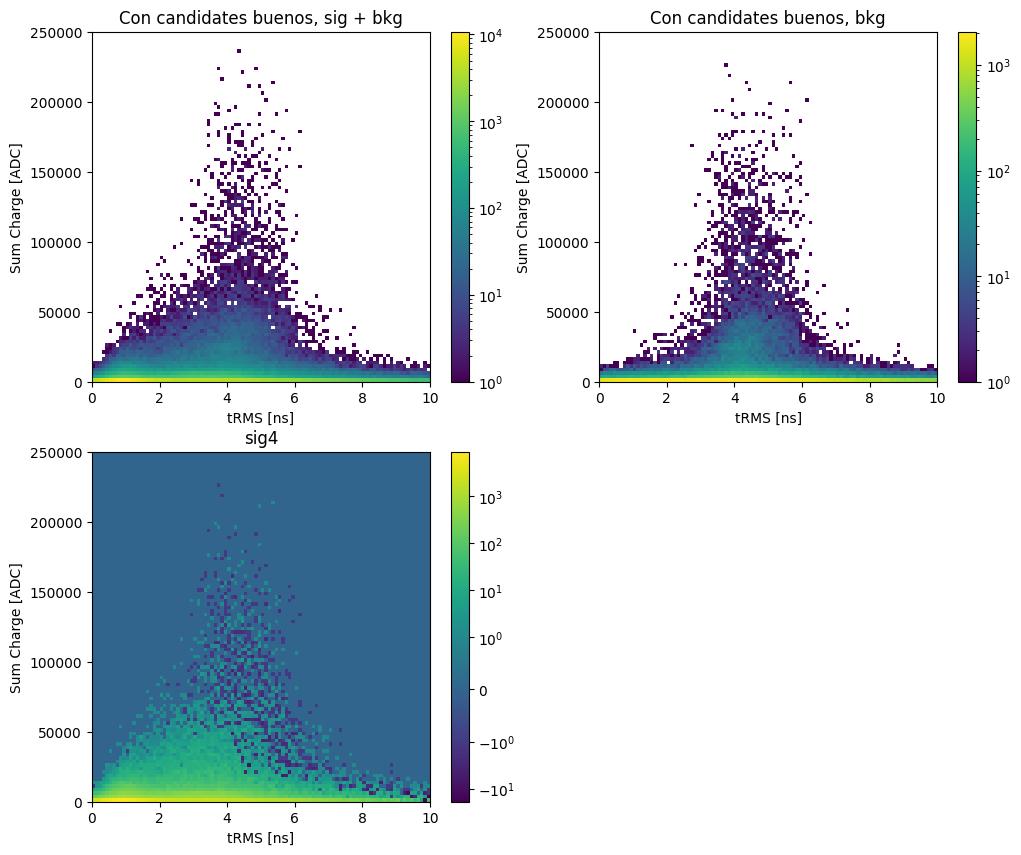

In [170]:
all_trms_2d = np.concatenate([total_trms_by_event_sig_clean, total_trms_by_event_bkg_clean])
all_charge_2d = np.concatenate([total_charge_by_event_sig_clean, total_charge_by_event_bkg_clean])
all_weights_2d = np.concatenate([np.ones_like(total_trms_by_event_sig_clean), -1*np.ones_like(total_trms_by_event_bkg_clean)])

subplot = pltext.canvas(3)

subplot(1)
plt.hist2d(total_trms_by_event_sig, total_charge_by_event_sig, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates buenos, sig + bkg")
plt.colorbar()

subplot(2)
plt.hist2d(total_trms_by_event_bkg, total_charge_by_event_bkg, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Con candidates buenos, bkg")
plt.colorbar()

subplot(3)  #para usar weights no puedo usar plt.hist2d, uso np.histogram2d()

bins_trms = np.linspace(0, 10, 101)     #creo 100 bins de 0.1 [ns] cada uno
bins_charge = np.linspace(0, 250e3, 101)    #creo 100 bins de 2500 [ADC] cada uno

H, xedges, yedges = np.histogram2d(all_trms_2d, all_charge_2d, bins=[bins_trms, bins_charge], weights=all_weights_2d)
#toma cada punto de all_trms_2d y all_charge_2d
#determina en qué bin cae según bins_tRMS y bins_charge
#en vez de sumar +1 a esa celda, suma el peso correspondiente de all_weights_2d
#resultado: crea la matriz 100x100:  H[i,j] = (eventos_sig+bkg_en_bin) - (eventos_bkg_en_bin)

plt.pcolormesh(xedges, yedges, H.T,norm=plt.matplotlib.colors.SymLogNorm(linthresh=1, linscale=1))
#dibuja malla de colores donde cada bin tiene el color correspondiente a su valor en H.T (traspuesta xq pcolormesh devuelve primero Y y leugo X)
#SymLogNorm para valores positivos y negativos, linthresh=1 : umbral para la región lineal, linscale=1 : escala de la región lineal

plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("sig4")
plt.colorbar()

# Automatización spills(?)

Pois así de primeiras, a maneira que se me ocorre a min é que ti podes percorrer todo o teu DataFrame de candidates e eliminar aqueles que teñan más de x hits, onde x é un threshold que ti estimas.

Por exemplo, do primeiro plot que envías vemos claramente que a liña basal está en torno a 7-8 (podes calcular a media de hits por candidate), mentres que os que sobresalen chegan a 40 ou así. Isto nos di que queremos quedarnos con aqueles candidates que teñen un número de hits dentro dos límites que poñemos nós (7-8 ou a media, ou media ponderada)

#df_filtrado = df[df["hits"] <= threshold] Sintaxis para esto


Text(0.5, 1.0, 'background con threshold 7')

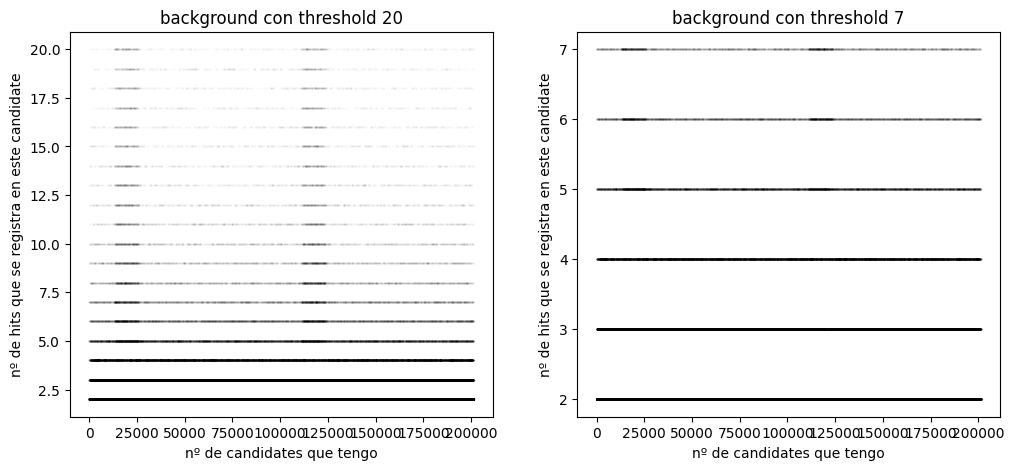

In [116]:
#para todos los candidates

clean_series_0 = total_nhits_by_event_bkg_spills

filtered_series_threshold20 = clean_series_0[clean_series_0 <= 20]
filtered_series_threshold7 = clean_series_0[clean_series_0 <= 7]

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(filtered_series_threshold20.index, filtered_series_threshold20.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background con threshold 20")

subplot(2)
plt.scatter(filtered_series_threshold7.index, filtered_series_threshold7.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background con threshold 7")



Text(0.5, 0.98, 'threshold 7')

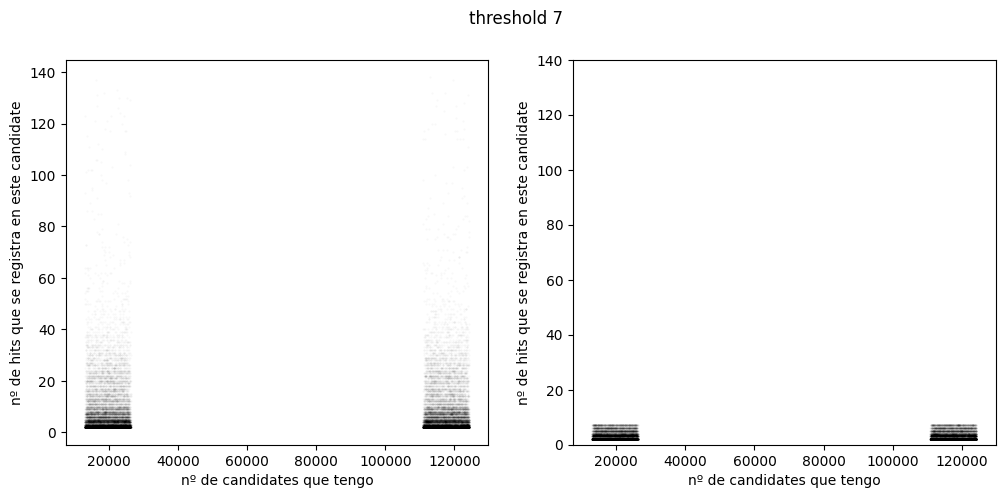

In [117]:
#para las regiones entre líneas rojas

#series que hay que quitar
clean_series_1 = clean_series_0[(clean_series_0.index >= x_min_s1) & (clean_series_0.index <= x_max_s1)]
clean_series_2 = clean_series_0[(clean_series_0.index >= x_min_s2) & (clean_series_0.index <= x_max_s2)]

#hay que concatenar sus índices, NO SUMAR

clean_series_combined = pd.concat([clean_series_1, clean_series_2])
#combined_indices = pd.concat([clean_series_1, clean_series_2]).index

filtered_series_red_lines_threshold7 = clean_series_combined[clean_series_combined <= 7]

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(clean_series_combined.index, clean_series_combined.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")

subplot(2)
plt.scatter(filtered_series_red_lines_threshold7.index, filtered_series_red_lines_threshold7.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.ylim(0,140)

plt.suptitle("threshold 7")

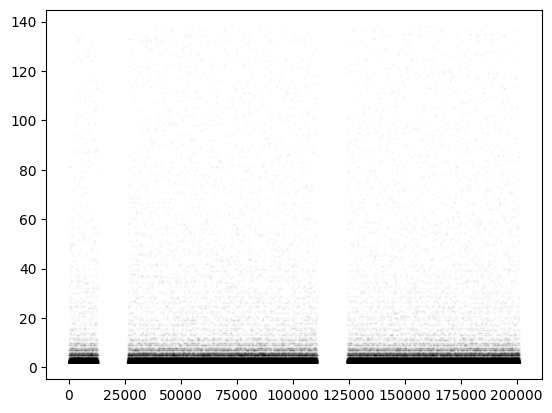

In [118]:
serie_de_las_barras = clean_series_combined.index

serie_total_menos_barras = clean_series_0.drop(serie_de_las_barras)
plt.scatter(serie_total_menos_barras.index, serie_total_menos_barras.values, s=0.2, alpha=0.03)

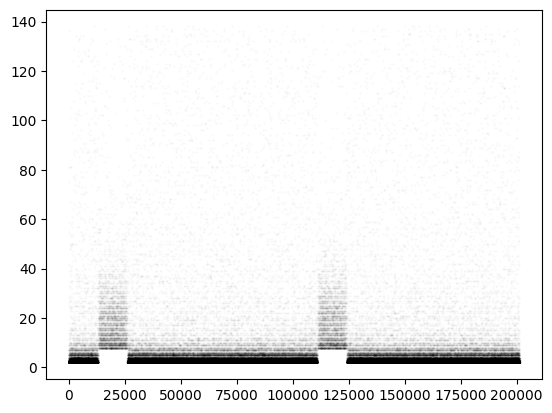

In [119]:
combined_indices_thershold7 = filtered_series_red_lines_threshold7.index
clean_series_total_threshold7 = clean_series_0.drop(combined_indices_thershold7)

plt.scatter(clean_series_total_threshold7.index, clean_series_total_threshold7.values, s=0.2, alpha=0.03)

# Esto ya es código de Diego

In [120]:
#data_bkg = data_bkg[(data_bkg["event_id"].values < 300e3) & (data_bkg["event_id"].values > 150e3)]
#data_sig = data_sig[(data_sig["event_id"].values < 0.4e6) & (data_sig["event_id"].values > 0)]

In [121]:
data_by_event_bkg=data_bkg.groupby("event_id")
total_charge_by_event_bkg=data_by_event_bkg["hit_pmt_charges"].sum() #data_by_event["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_event_bkg = data_by_event_bkg.size()
total_trms_by_event_bkg  = data_by_event_bkg["hit_pmt_calibrated_times"].std()

data_by_event_sig=data_sig.groupby("event_id")
total_charge_by_event_sig=data_by_event_sig["hit_pmt_charges"].sum()
total_nhits_by_event_sig = data_by_event_sig.size()
total_trms_by_event_sig  = data_by_event_sig["hit_pmt_calibrated_times"].std()
#######################################################################
# #la columna hit_pmt_charges de cada grupo y luego sumamos sus valores
# print(total_charge_by_event)

# #==============CHATTY===========================================
# # Busco los 30 eventos con más hits
# top_30_charge=total_charge_by_event.nlargest(30) #crea una serie con los 30 valores más grandes de total_charge_by_event

# print("="*60)
# print("TOP 30 EVENTOS CON MÁS CARGA TOTAL")
# print("="*60)

# # Convertir a DataFrame con ranking desde 1
# top_30_df = top_30_charge.reset_index()
# top_30_df.columns = ['event_id', 'carga total']
# top_30_df.index = top_30_df.index + 1
# top_30_df.index.name = 'ranking'

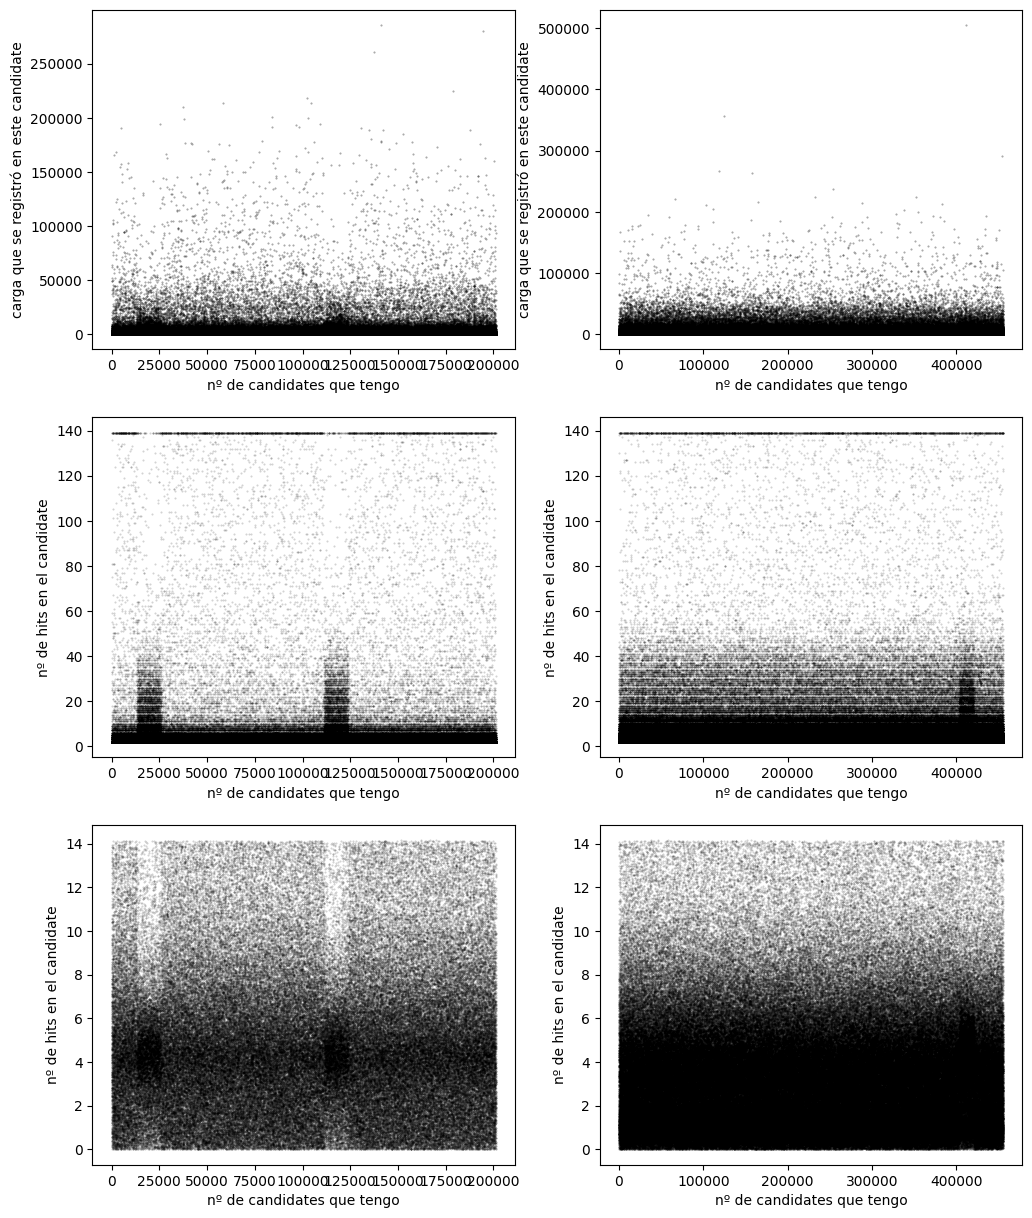

In [122]:
subplot = pltext.canvas(6)  #ME DESAPARECEN LOS SPILLS??

subplot(1)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.4)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registró en este candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
#plt.ylim(0, 50e3); 

subplot(2)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.4)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registró en este candidate")
#plt.ylim(0, 50e3);

subplot(3)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(4)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(5)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(6)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

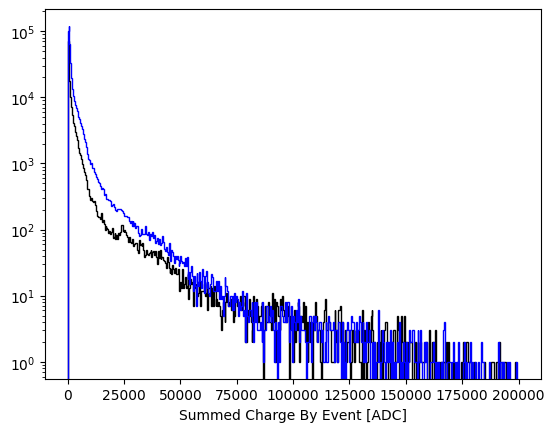

In [123]:
plt.hist(total_charge_by_event_bkg, 500, histtype="step", range=(0, 200e3));
plt.hist(total_charge_by_event_sig, 500, histtype="step", range=(0, 200e3));
plt.xlabel("Summed Charge By Event [ADC]");
plt.yscale("log");

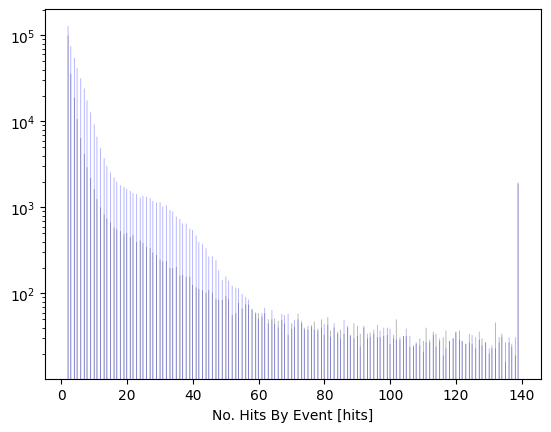

In [124]:
plt.hist(total_nhits_by_event_bkg, 500, histtype="stepfilled", alpha=0.3);
plt.hist(total_nhits_by_event_sig, 500, histtype="stepfilled", alpha=0.3);
plt.xlabel("No. Hits By Event [hits]");
plt.yscale("log");

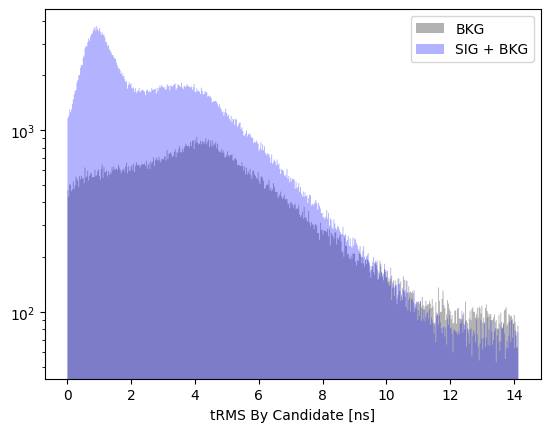

In [125]:
plt.hist(total_trms_by_event_bkg, 500, histtype="stepfilled", alpha=0.3, label="BKG");
plt.hist(total_trms_by_event_sig, 500, histtype="stepfilled", alpha=0.3, label="SIG + BKG");
plt.xlabel("tRMS By Candidate [ns]");
plt.yscale("log");
plt.legend();

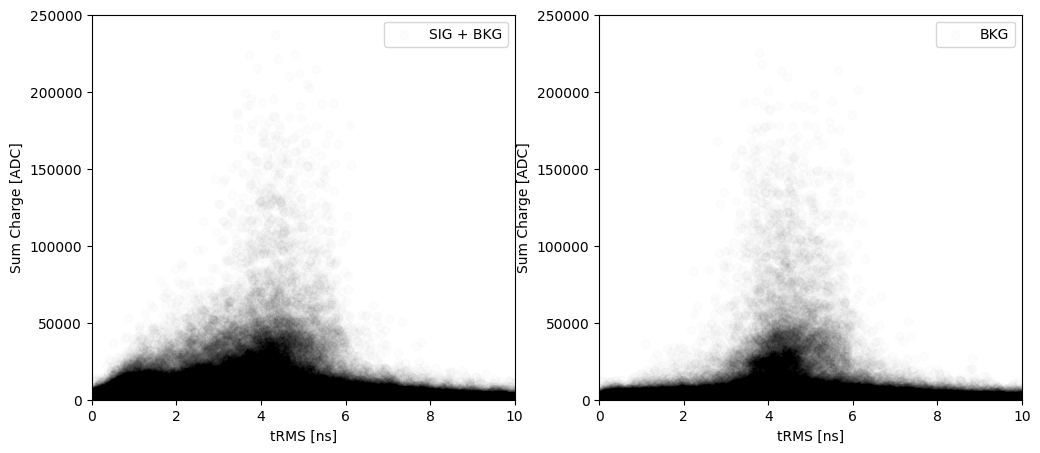

In [126]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_trms_by_event_sig, total_charge_by_event_sig, alpha=0.01, label="SIG + BKG");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);
plt.legend()

subplot(2)
plt.scatter(total_trms_by_event_bkg, total_charge_by_event_bkg, alpha=0.01, label="BKG");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);
plt.legend();

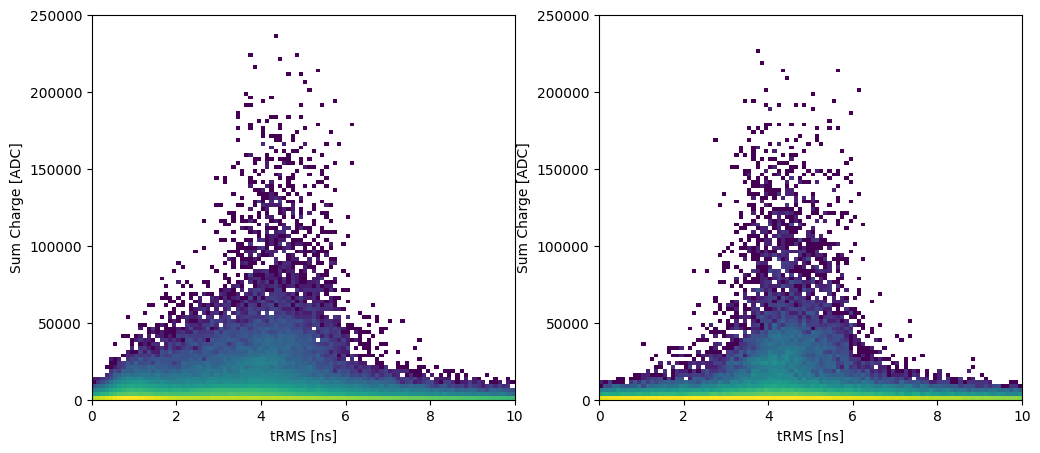

In [127]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist2d(total_trms_by_event_sig, total_charge_by_event_sig, (100, 100), range=((0, 10), (0, 250e3)), norm="log");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);

subplot(2)
plt.hist2d(total_trms_by_event_bkg, total_charge_by_event_bkg, (100, 100), range=((0, 10), (0, 250e3)), norm="log");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);